# `sc_inj` Impact-T

In [1]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from impact import Impact
from distgen import Generator
from pmd_beamphysics import ParticleGroup, single_particle
import numpy as np

In [4]:
#P0 = ParticleGroup( '$LCLS_LATTICE/bmad/models/sc_inj/cathode_probe_particles.h5')
#P0.weight = 1.0
#P0.pz = 1
#P0.pz

# Distgen particles

In [5]:
DISTGEN_IN = '$LCLS_LATTICE/distgen/models/sc_inj/v0/distgen.yaml'

G = Generator(DISTGEN_IN)
G['n_particle'] = 10_000
G

<disgten.Generator with input: 
n_particle: 10000
r_dist:
  max_r:
    units: mm
    value: 0.5
  type: radial_uniform
random_type: hammersley
start:
  MTE:
    units: meV
    value: 330
  type: cathode
t_dist:
  avg_t:
    units: ps
    value: 0
  n_sigma_cutoff: 3
  sigma_t:
    units: ps
    value: 8.5
  type: gaussian
total_charge:
  units: pC
  value: 100

>

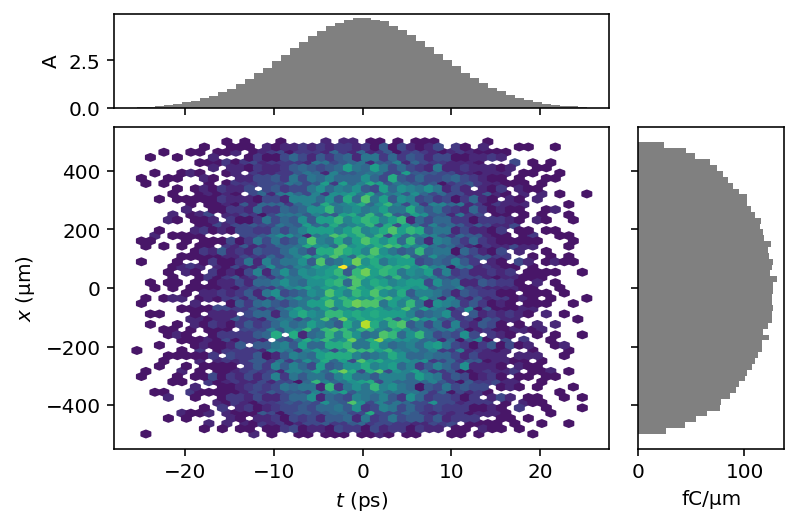

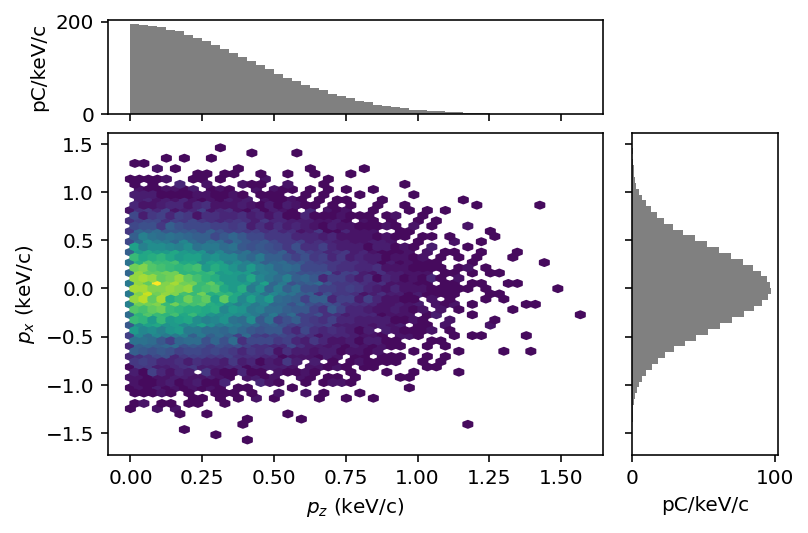

In [6]:
# Make the particles
G.run()
P0 = G.particles
P0.plot('t', 'x')
P0.plot('pz', 'px')

# Impact

Setting Npcol, Nprow = 4, 2
Enabling MPI
Running Impact-T in /var/folders/2f/l5_mybzs30j4qqvyj98w1_nw0000gn/T/tmp2z87f2l7
mpirun -n 8 /Users/chrisonian/Code/GitHub/IMPACT-T/build-mpi/ImpactTexe-mpi
writing 10000 particles to /var/folders/2f/l5_mybzs30j4qqvyj98w1_nw0000gn/T/tmp2z87f2l7/partcl.data
Cathode start with cathode_kinetic_energy_ref = 1.0 eV
Cathode start: Replaced Np with 10000 according to initial particles
Cathode start: Replaced Bkenergy with 1.0 according to initial particles
Cathode start: Replaced Temission with 5.0643085710098247e-11 according to initial particles
Cathode start: Replaced Tini with -2.5403549006681168e-11 according to initial particles
 !-----------------------------------------------------------
 ! IMPACT-T Parallel Beam Dynamics Tracking Code: 2.1 beta version
 ! Copyright of The Regents of the University of California
 !-----------------------------------------------------------
 nblem:           17          17
 pass setting up lattice...
 check rand

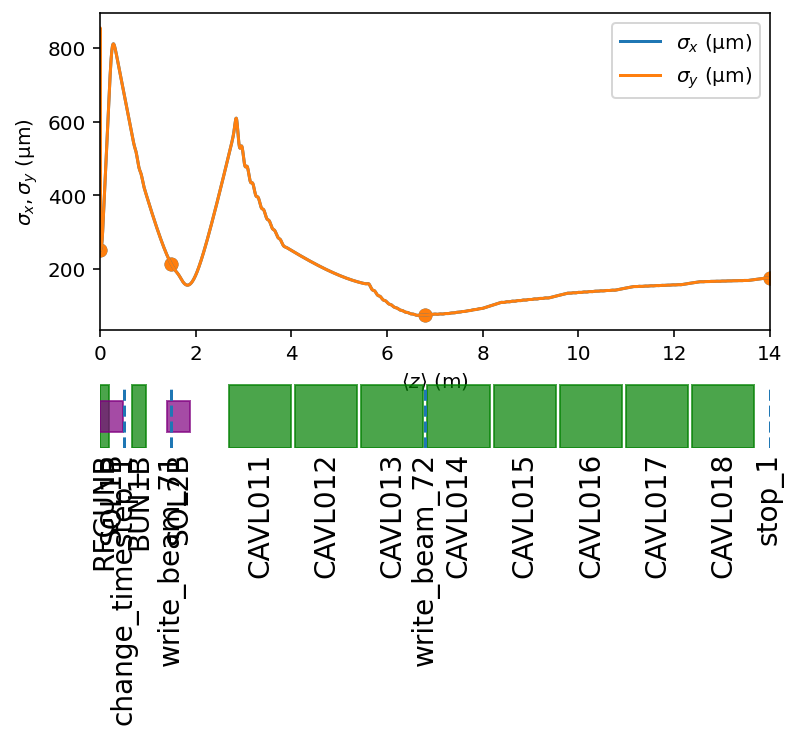

In [7]:
IMPACT_IN = '$LCLS_LATTICE/impact/models/sc_inj/v1/ImpactT.in'

ZSTOP = 14

I = Impact(IMPACT_IN, initial_particles=P0)
#I.header['Flagimg'] = 1
#I.header['Flagdiag'] = 2
#I.header['Nemission'] = 400
I.ele['stop_1']['s'] = ZSTOP

I.verbose=True
I.numprocs = 8

I.header['Bcurr'] = 0 # Turn off SC
#I.total_charge = 100e-12

#I.write_input()
I.run()
#I.track1()
I.plot(xlim=(0, ZSTOP), include_labels=True)

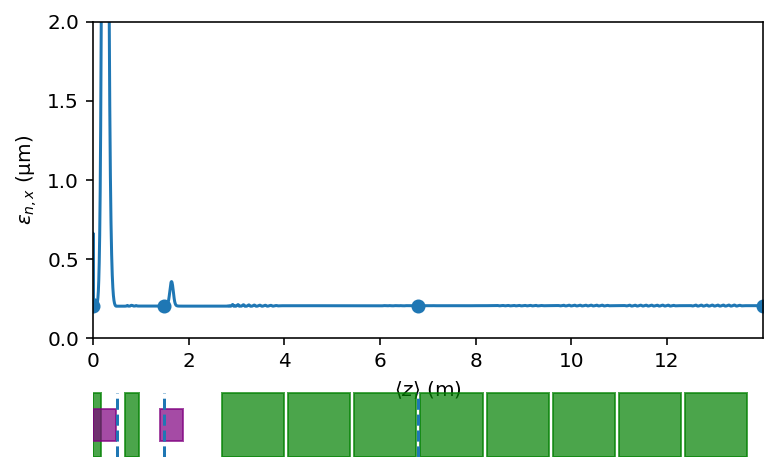

In [8]:
I.plot('norm_emit_x', ylim=(0,2e-6))

# Plots

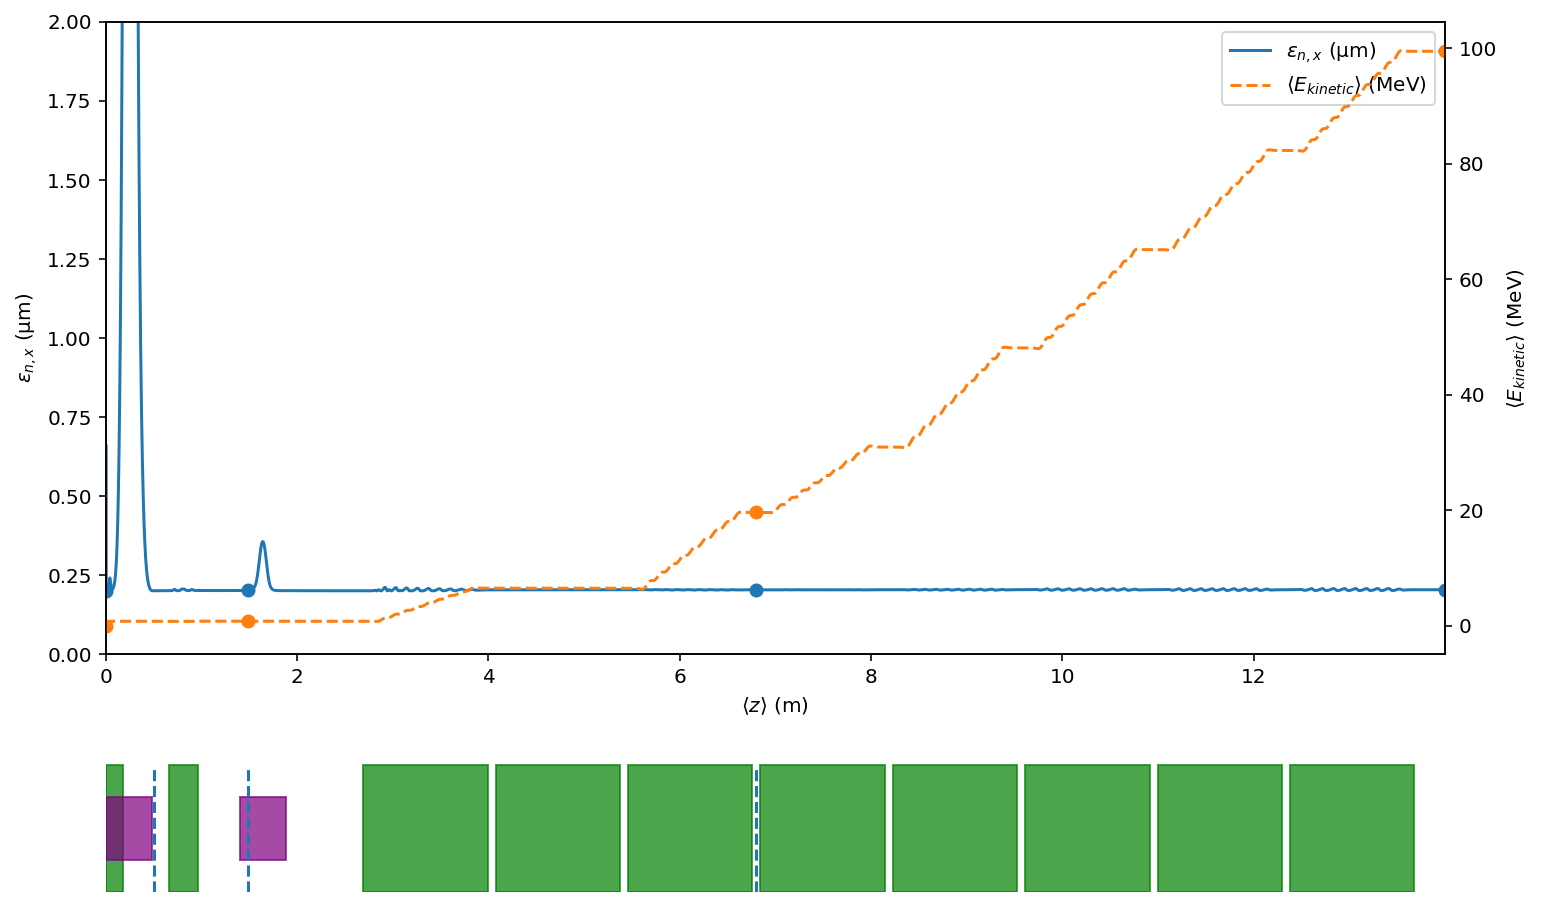

In [9]:
I.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(12,8))

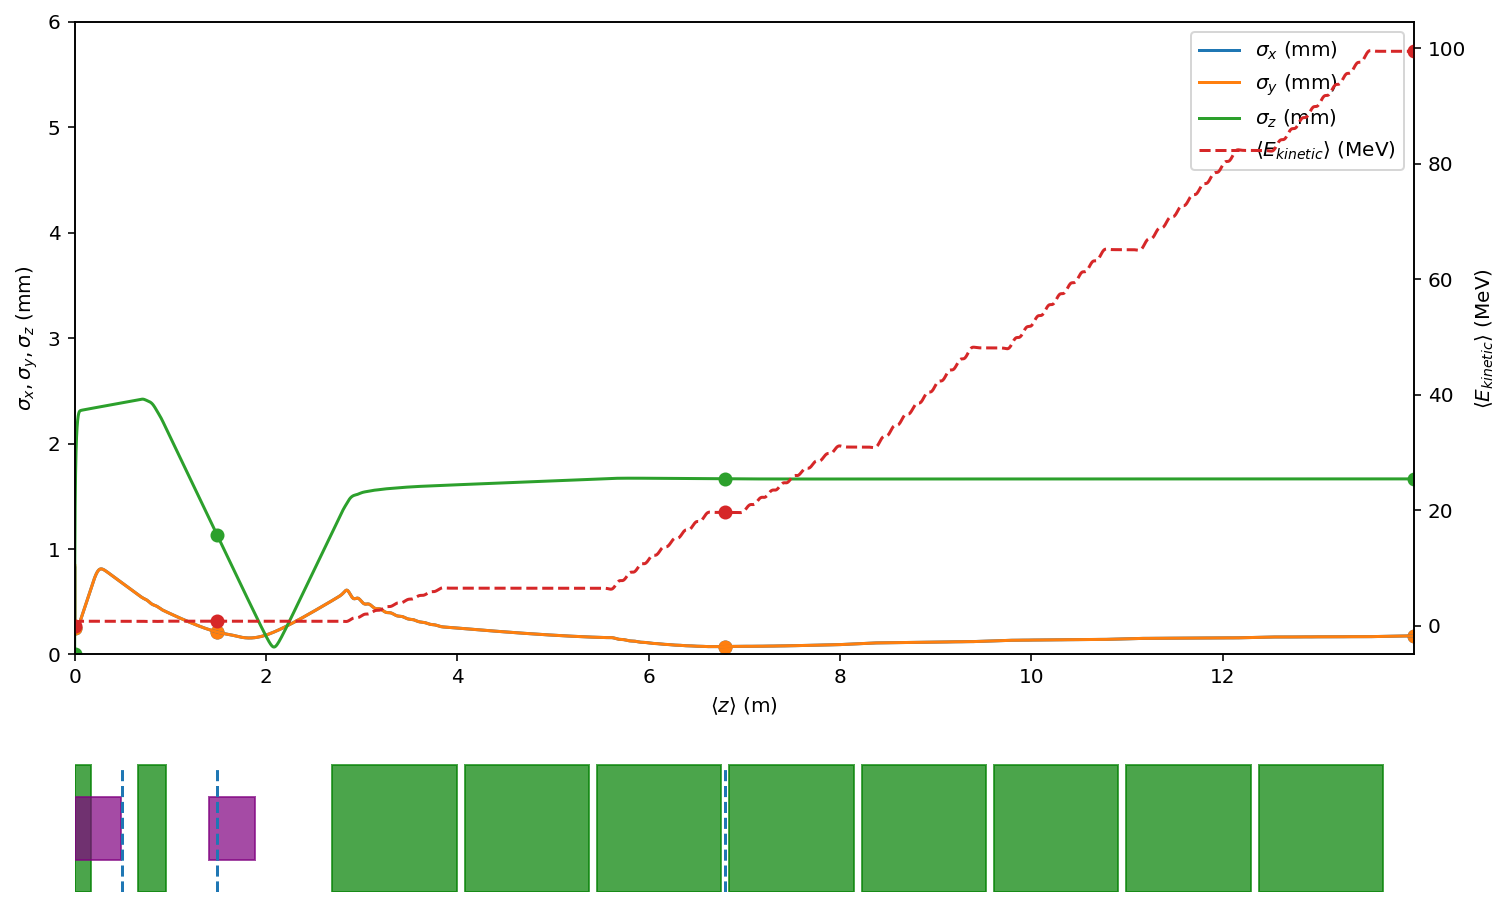

In [10]:
I.plot(['sigma_x', 'sigma_y', 'sigma_z'], y2='mean_kinetic_energy', ylim=(0, 6e-3), figsize=(12,8))

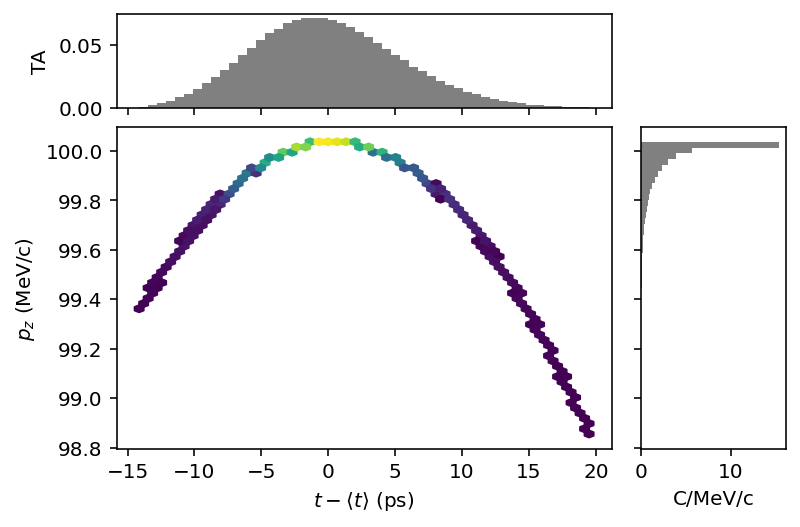

In [11]:
Pf = I.particles['final_particles'].copy()
Pf.drift_to_z()
Pf.plot('delta_t', 'pz')

# Compare with Astra

In [12]:
from astra import Astra
A = Astra.from_archive('$LCLS_LATTICE/astra/models/sc_inj/v1/astra_sc_inj_v1.h5')

In [13]:
# Re-run without space charge
A.input['output']['zstop'] = ZSTOP
A.input['charge']['lspch'] = False
A.configure()
#A.verbose=True
A.initial_particles = P0
A.run()

In [14]:
A.particles[-1]['norm_emit_x']

2.0427486886272732e-07

(6e-09, 0.0001)

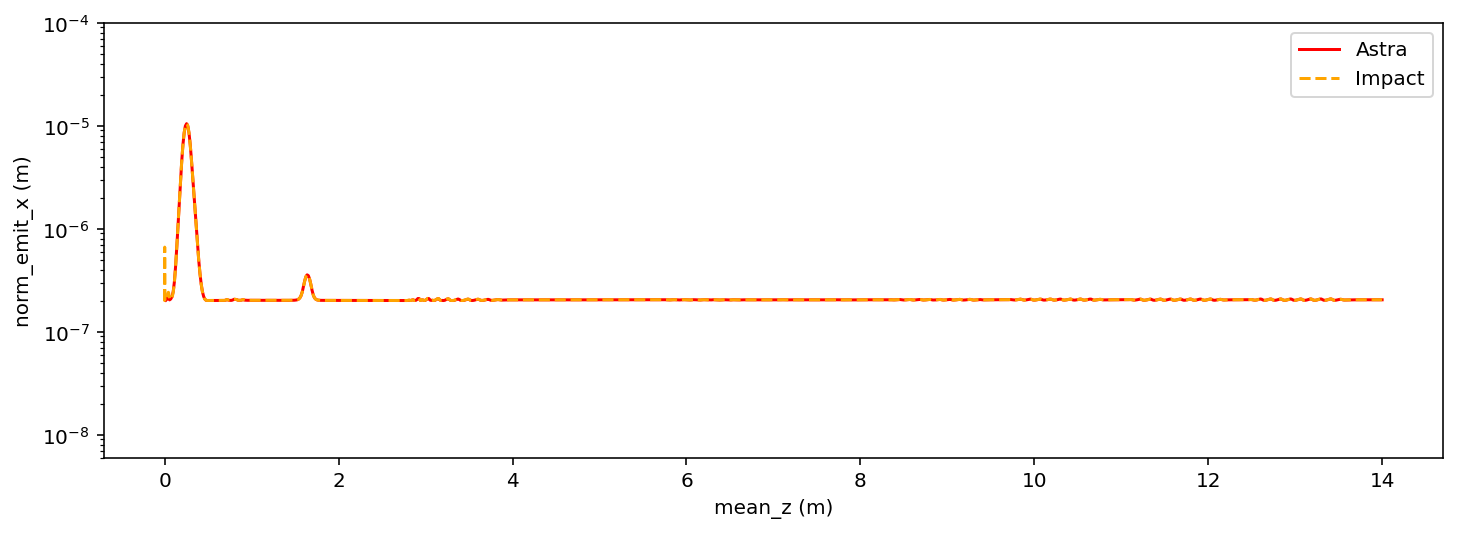

In [15]:
def compare(ykey, xkey = 'mean_z', ylim=None):
    xunits = I.units(xkey)
    yunits = I.units(ykey)
    
    fig, ax = plt.subplots(figsize=(12,4))
    
    ax.plot(A.stat(xkey), A.stat(ykey), label='Astra', color='red')
    ax.plot(I.stat(xkey), I.stat(ykey), '--', label='Impact', color='orange')
    ax.set_xlabel(f'{xkey} ({xunits})')
    ax.set_ylabel(f'{ykey} ({yunits})')
    ax.set_ylim(ylim)
    plt.legend()
    
compare('norm_emit_x', ylim=(0, 3e-6))
plt.yscale('log')
plt.ylim(6e-9, 1e-4)

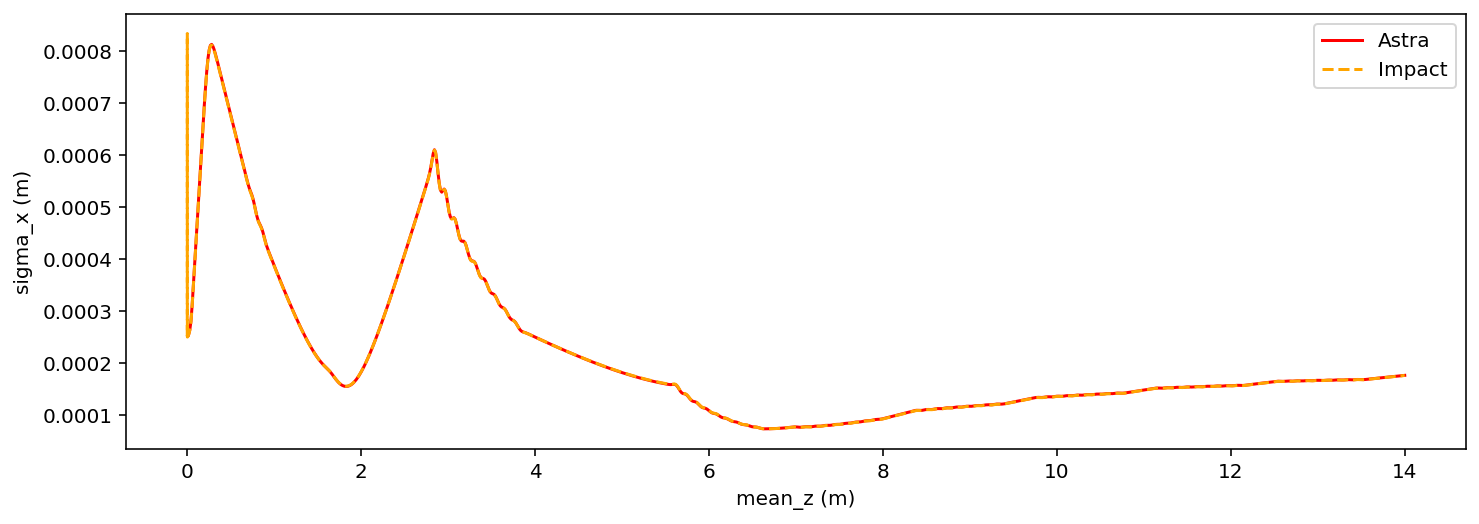

In [16]:
compare('sigma_x')

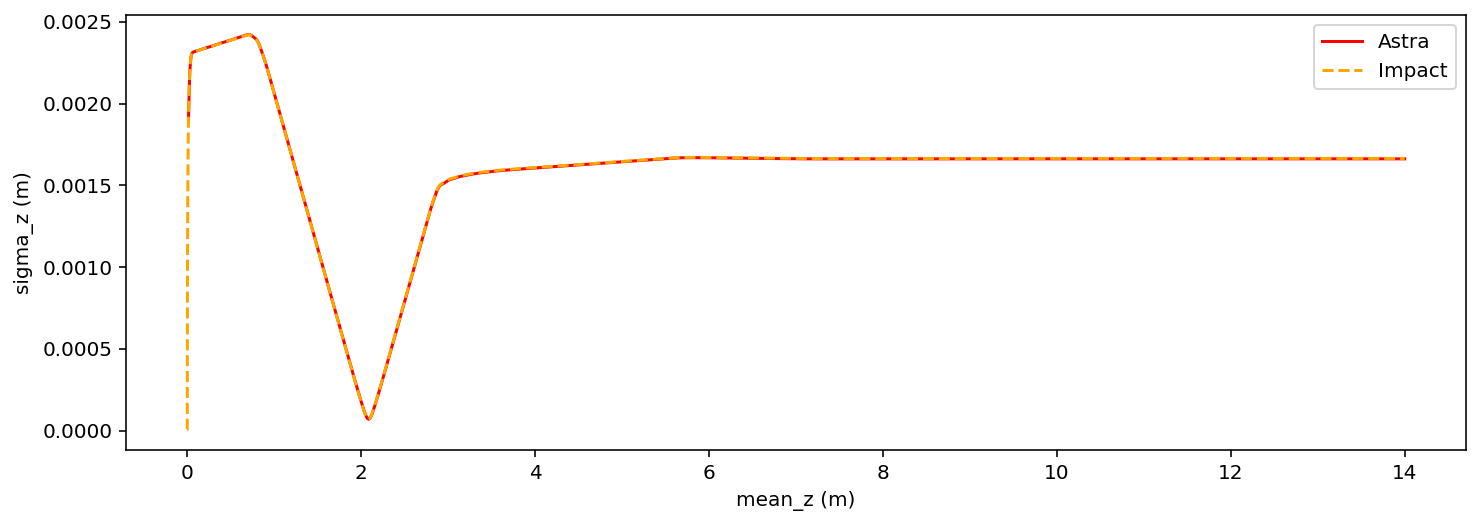

In [17]:
compare('sigma_z')

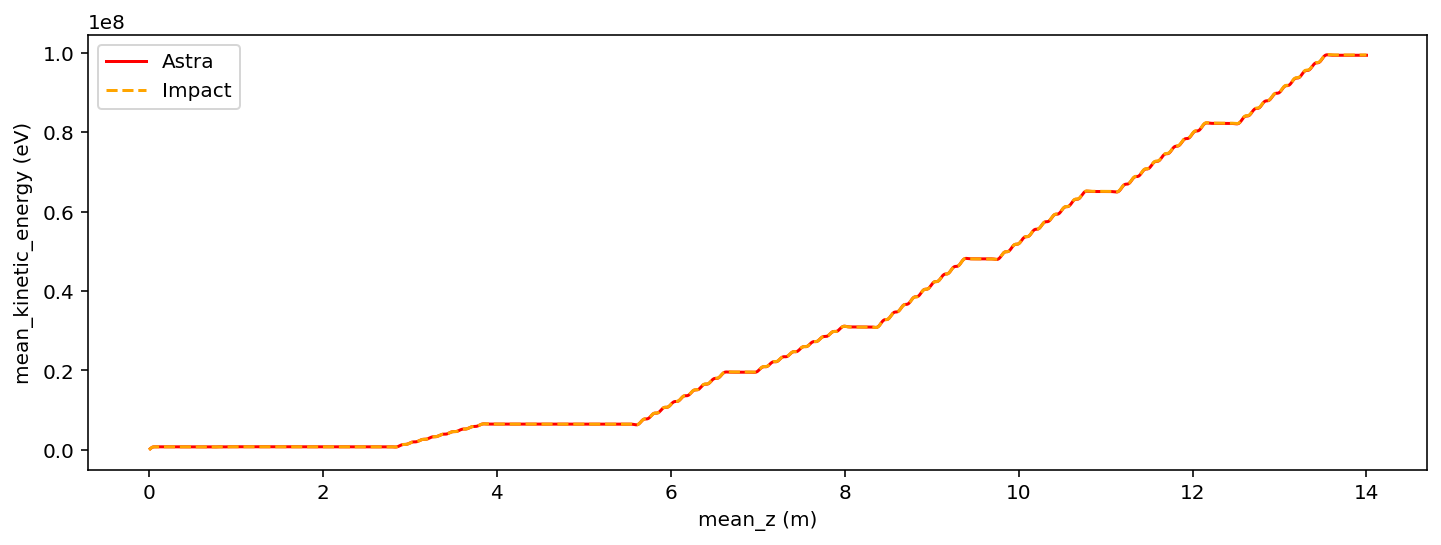

In [18]:
compare('mean_kinetic_energy')

In [19]:
Pa = A.particles[-1].copy()
Pa.drift_to_z(ZSTOP)
Pa.drift_to_t()
Pa['mean_z']

13.999999999973943

In [20]:
Pi = I.particles['final_particles'].copy()
Pi.drift_to_z(ZSTOP)
Pi.drift_to_t()
Pi['mean_z']

14.000000000008546

In [21]:
Pa['mean_energy']/Pi['mean_energy']

0.999266404324051

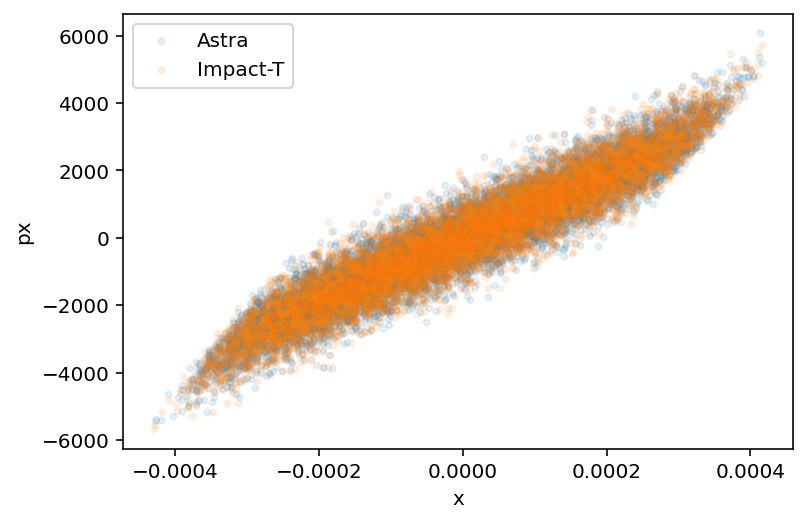

In [22]:
def compare_particles(key1, key2, skip=1):
    for name, P in (("Astra", Pa), ("Impact-T", Pi)):
        plt.scatter(P[key1][::skip], P[key2][::skip], marker='.', alpha=0.1, label=name)
        plt.xlabel(key1)
        plt.ylabel(key2)
    plt.legend()
        
compare_particles('x', 'px')        


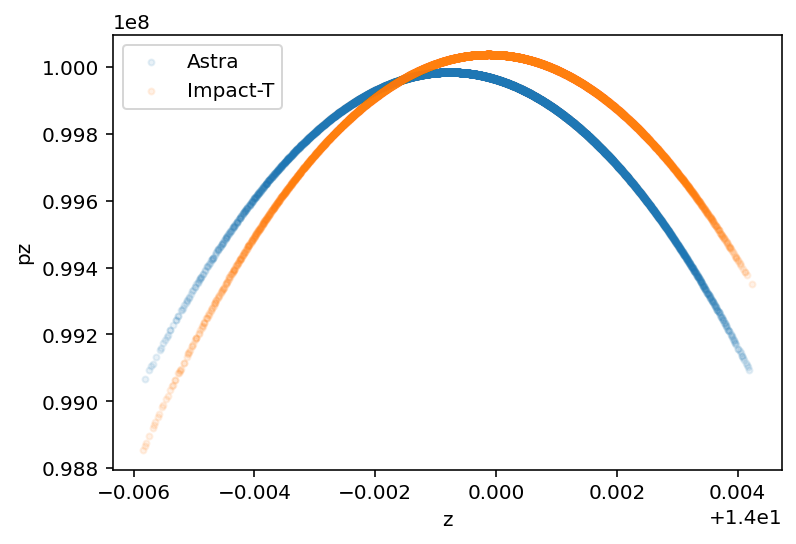

In [23]:
compare_particles('z', 'pz')  

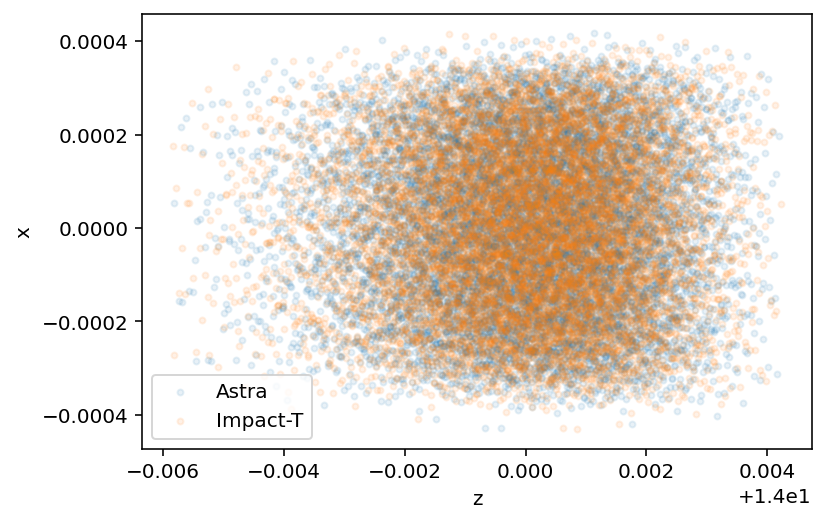

In [24]:
compare_particles('z', 'x')  

# Scan `SOL2B`

In [ ]:
from concurrent.futures import ProcessPoolExecutor
# Allows processes to work with macOS
from sys import platform 
if platform == 'darwin':
    import multiprocessing as mp
    mp.set_start_method("fork")

In [ ]:
Iref = I.copy()
Pref = I.particles['write_beam_71'].copy()
Iref.output = {}
x0 = Iref.ele['SOL2B']['solenoid_field_scale']
x0

In [ ]:
xlist = np.linspace(0.9*x0, 1.1*x0, 8)
xlist

In [ ]:
%%time
def set1(x, ele='SOL2B', component='solenoid_field_scale'): 
    I2 = Iref.copy()
    I2.verbose=False
    I2.configure()
    I2.numprocs = 1
    I2.ele[ele][component] = x
    I2.initial_particles = Pref
    I2.run()
    return I2

#I2 = set1(x0)

In [ ]:
%%time
with ProcessPoolExecutor(max_workers=8) as executor:
    results1 = list(executor.map(set1, xlist))    

In [ ]:
def compare(ykey, xkey = 'mean_z', ylim=None):
    xunits = I.units(xkey)
    yunits = I.units(ykey)
    
    fig, ax = plt.subplots(figsize=(12,8))
    
    for name, I9 in enumerate(results1):
        ax.plot(I9.stat(xkey), I9.stat(ykey), label='x')
    ax.set_xlabel(f'{xkey} ({xunits})')
    ax.set_ylabel(f'{ykey} ({yunits})')
    ax.set_ylim(ylim)
    plt.legend()
    
compare('norm_emit_x', ylim=(1e-6, 1e-3)    )
plt.yscale('log')

In [ ]:
results1
y1 = np.array(list(map(lambda ii: ii.particles['final_particles'].twiss('x', 1)['norm_emit_x'], results1)))
y2 = np.array(list(map(lambda ii: ii.particles['final_particles'].twiss('x', 0.95)['norm_emit_x'], results1)))
plt.plot(xlist, y1)
plt.plot(xlist, y2)

In [ ]:
y1.argmin()

In [ ]:
xlist[]

In [ ]:
I2 = results1[4]
I2.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(12,8))